In [92]:
import pandas as pd
import numpy as np

print("Python environment is working!")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Python environment is working!
Pandas version: 3.0.6
NumPy version: 2.5.3


In [93]:
nyc = pd.read_csv("../data/NYC/listings.csv.gz")
paris = pd.read_csv("../data/Paris/listings (1).csv.gz")
berlin = pd.read_csv("../data/berlin/listings (2).csv.gz")

print("NYC shape:", nyc.shape)
print("Paris shape:", paris.shape)
print("Berlin shape:", berlin.shape)

NYC shape: (30259, 90)
Paris shape: (77679, 90)
Berlin shape: (12776, 90)


In [94]:
print("NYC columns:")
print(nyc.columns.tolist())

print("\nParis columns:")
print(paris.columns.tolist())

print("\nBerlin columns:")
print(berlin.columns.tolist())

NYC columns:
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote_price_per_night', 'price_quote_raw',

In [95]:
# Display all available features

print("Number of columns:", len(nyc.columns))

for i, col in enumerate(nyc.columns, start=1):
    print(f"{i}. {col}")

Number of columns: 90
1. id
2. listing_url
3. scrape_id
4. last_scraped
5. source
6. name
7. description
8. neighborhood_overview
9. picture_url
10. host_id
11. host_url
12. host_profile_id
13. host_profile_url
14. host_name
15. host_since
16. hosts_time_as_user_years
17. hosts_time_as_user_months
18. hosts_time_as_host_years
19. hosts_time_as_host_months
20. host_location
21. host_about
22. host_response_time
23. host_response_rate
24. host_acceptance_rate
25. host_is_superhost
26. host_thumbnail_url
27. host_picture_url
28. host_neighbourhood
29. host_listings_count
30. host_total_listings_count
31. host_verifications
32. host_has_profile_pic
33. host_identity_verified
34. neighbourhood
35. neighbourhood_cleansed
36. neighbourhood_group_cleansed
37. latitude
38. longitude
39. property_type
40. room_type
41. accommodates
42. bathrooms
43. bathrooms_text
44. bedrooms
45. beds
46. amenities
47. price
48. price_quote_checkin_date
49. price_quote_checkout_date
50. price_quote_total_price


In [96]:
# Preview the dataset

nyc.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2539,https://www.airbnb.com/rooms/2539,20260614073253,2026-06-15,city scrape,11 Min to Manhattan • Prospect Park • Fast WiFi,"Bright, serene room in a renovated apartment h...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,2787,...,5.00,4.78,4.78,NaN,NaN,5,0,5,0,0.08
1,6848,https://www.airbnb.com/rooms/6848,20260614073253,2026-06-14,city scrape,Only 2 stops to Manhattan studio,Comfortable studio apartment with super comfor...,NaN,https://a0.muscache.com/pictures/e4f031a7-f146...,15991,...,4.80,4.69,4.59,NaN,NaN,1,1,0,0,0.95
2,6872,https://www.airbnb.com/rooms/6872,20260614073253,2026-06-14,city scrape,Uptown Sanctuary w/ Private Bath (Month to Month),This charming distancing-friendly month-to-mon...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,16104,...,5.00,5.00,5.00,NaN,NaN,2,0,2,0,0.04
3,6990,https://www.airbnb.com/rooms/6990,20260614073253,2026-06-14,city scrape,UES Beautiful Blue Room,Beautiful peaceful healthy home,NaN,https://a0.muscache.com/pictures/45fb4ec7-6856...,16800,...,4.94,4.85,4.84,NaN,NaN,1,0,1,0,1.24
4,7097,https://www.airbnb.com/rooms/7097,20260614073253,2026-06-14,city scrape,"Perfect for Your Parents, With Garden & Patio",Parents/grandparents coming to town or are you...,NaN,https://a0.muscache.com/pictures/aaac19fc-4b4d...,17571,...,4.93,4.95,4.82,NaN,NaN,2,0,2,0,2.12


In [97]:
# Check the target variable

print("NYC price datatype:", nyc["price"].dtype)
print("Sample prices:")
print(nyc["price"].head(10))

NYC price datatype: str
Sample prices:
0    $113.97
1    $117.27
2     $80.06
3     $77.17
4    $202.47
5    $365.97
6    $154.87
7     $91.07
8        NaN
9        NaN
Name: price, dtype: str


In [98]:
# Clean the price column

nyc["price"] = (
    nyc["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

nyc["price"] = pd.to_numeric(nyc["price"], errors="coerce")

print("NYC price datatype:", nyc["price"].dtype)
print("Missing prices:", nyc["price"].isna().sum())
print("Sample cleaned prices:")
print(nyc["price"].head(10))

NYC price datatype: float64
Missing prices: 8744
Sample cleaned prices:
0    113.97
1    117.27
2     80.06
3     77.17
4    202.47
5    365.97
6    154.87
7     91.07
8       NaN
9       NaN
Name: price, dtype: float64


In [99]:
# Check missing values

print("Missing values in important columns:")
print(nyc[["price", "minimum_nights", "number_of_reviews",
           "reviews_per_month", "availability_365"]].isna().sum())

Missing values in important columns:
price                8744
minimum_nights          2
number_of_reviews       0
reviews_per_month    8559
availability_365        0
dtype: int64


In [100]:
# Check overall missing values

missing = nyc.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

neighborhood_overview          30259
host_since                     30259
host_neighbourhood             30259
host_verifications             30259
host_total_listings_count      30259
host_thumbnail_url             30259
host_response_time             30259
host_acceptance_rate           30259
host_response_rate             30259
calendar_updated               30259
instant_bookable               30259
neighbourhood                  30259
license                        24973
host_about                     12410
bedrooms                       10973
bathrooms                      10112
beds                            9420
price_quote_price_per_night     8745
price_quote_total_price         8745
estimated_revenue_l365d         8744
price                           8744
review_scores_value             8568
review_scores_location          8568
review_scores_checkin           8567
review_scores_accuracy          8565
review_scores_communication     8562
review_scores_cleanliness       8559
r

In [101]:
# List all dataset columns

for i, col in enumerate(nyc.columns, 1):
    print(i, col)

1 id
2 listing_url
3 scrape_id
4 last_scraped
5 source
6 name
7 description
8 neighborhood_overview
9 picture_url
10 host_id
11 host_url
12 host_profile_id
13 host_profile_url
14 host_name
15 host_since
16 hosts_time_as_user_years
17 hosts_time_as_user_months
18 hosts_time_as_host_years
19 hosts_time_as_host_months
20 host_location
21 host_about
22 host_response_time
23 host_response_rate
24 host_acceptance_rate
25 host_is_superhost
26 host_thumbnail_url
27 host_picture_url
28 host_neighbourhood
29 host_listings_count
30 host_total_listings_count
31 host_verifications
32 host_has_profile_pic
33 host_identity_verified
34 neighbourhood
35 neighbourhood_cleansed
36 neighbourhood_group_cleansed
37 latitude
38 longitude
39 property_type
40 room_type
41 accommodates
42 bathrooms
43 bathrooms_text
44 bedrooms
45 beds
46 amenities
47 price
48 price_quote_checkin_date
49 price_quote_checkout_date
50 price_quote_total_price
51 price_quote_price_per_night
52 price_quote_raw
53 minimum_nights
54 m

In [102]:
# Find price-related columns

price_cols = [col for col in nyc.columns if "price" in col.lower()]

print("Price-related columns:")
for col in price_cols:
    print(col)

Price-related columns:
price
price_quote_checkin_date
price_quote_checkout_date
price_quote_total_price
price_quote_price_per_night
price_quote_raw


In [103]:
# Inspect price-related columns

price_cols = [
    "price",
    "price_quote_checkin_date",
    "price_quote_checkout_date",
    "price_quote_total_price",
    "price_quote_price_per_night",
    "price_quote_raw"
]

nyc[price_cols].head(10)

,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_total_price,price_quote_price_per_night,price_quote_raw
0,113.97,2026-07-11,2026-08-10,3419.19,113.97,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""..."
1,117.27,2026-12-20,2027-01-19,3518.00,117.27,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""..."
2,80.06,2026-09-01,2026-10-01,2401.84,80.06,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""..."
3,77.17,2026-12-06,2027-01-05,2315.00,77.17,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""..."
4,202.47,2027-02-28,2027-03-30,6074.17,202.47,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""..."
5,365.97,2027-01-02,2027-02-01,10979.00,365.97,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""..."
6,154.87,2026-07-01,2026-07-31,4646.00,154.87,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""..."
7,91.07,2026-07-01,2026-07-31,2731.98,91.07,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""..."
8,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN


In [104]:
# Convert price from string to numeric

nyc["price_clean"] = (
    nyc["price"]
    .astype("string")
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

nyc["price_clean"] = pd.to_numeric(nyc["price_clean"], errors="coerce")

print("Price datatype:", nyc["price_clean"].dtype)
print(nyc["price_clean"].describe())

Price datatype: Float64
count       21515.0
mean     278.229518
std      531.730477
min            4.58
25%          96.875
50%          174.69
75%          302.72
max        30972.96
Name: price_clean, dtype: Float64


In [105]:
# Check cleaned price values

print("Missing prices:", nyc["price_clean"].isna().sum())
print("Sample cleaned prices:")
print(nyc["price_clean"].head(10))

Missing prices: 8744
Sample cleaned prices:
0    113.97
1    117.27
2     80.06
3     77.17
4    202.47
5    365.97
6    154.87
7     91.07
8      <NA>
9      <NA>
Name: price_clean, dtype: Float64


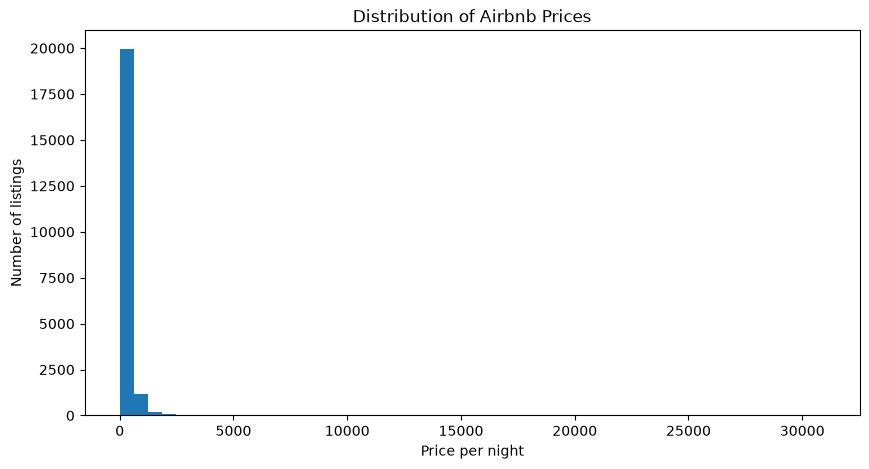

In [106]:
# Check price distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(nyc["price_clean"].dropna(), bins=50)
plt.xlabel("Price per night")
plt.ylabel("Number of listings")
plt.title("Distribution of Airbnb Prices")
plt.show()

In [107]:
# Check price outliers using IQR

q1 = nyc["price_clean"].quantile(0.25)
q3 = nyc["price_clean"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

outliers = nyc[
    (nyc["price_clean"] < lower_bound) |
    (nyc["price_clean"] > upper_bound)
]

print("Number of outliers:", len(outliers))
print("Percentage of outliers:", round(len(outliers) / nyc["price_clean"].notna().sum() * 100, 2), "%")

Q1: 96.875
Q3: 302.72
IQR: 205.84500000000003
Lower bound: -211.89250000000004
Upper bound: 611.4875000000001
Number of outliers: 1608
Percentage of outliers: 7.47 %


In [108]:
# Inspect the most expensive listings

print(nyc["price_clean"].nlargest(20).to_list())

[30972.96, 14864.0, 14864.0, 12279.07, 12078.47, 11061.8, 11061.8, 10986.0, 10986.0, 10986.0, 10986.0, 10944.83, 10000.0, 10000.0, 10000.0, 9690.48, 9532.76, 9439.38, 9107.53, 8296.33]


In [109]:
# Inspect listings with very high prices

high_price = nyc[nyc["price_clean"] > 5000]

print("Listings above $5,000:", len(high_price))

high_price[
    ["id", "name", "room_type", "price_clean",
     "minimum_nights", "maximum_nights",
     "number_of_reviews", "availability_365"]
].head(20)

Listings above $5,000: 38


,id,name,room_type,price_clean,minimum_nights,maximum_nights,number_of_reviews,availability_365
731,1623431,Enormous Chrysler-View Bedroom/Bath,Private room,12078.47,30.0,180.0,1,83
798,990529,Sunny Luxury Bedroom Guest Bathroom,Private room,12279.07,30.0,180.0,3,83
4698,15345019,NYC Firehouse-Greenpoint BRKLYN,Private room,8171.32,31.0,1125.0,29,358
8268,34368310,NEW ! Chic Designer Blue,Private room,9690.48,30.0,45.0,261,263
9352,39553889,"Paper Factory, Executive King",Private room,10000.0,1.0,1125.0,3,365
9353,39554366,"Paper Factory, Superior Room w/ Double Beds",Private room,10000.0,1.0,1125.0,13,365
9354,39554839,"Paper Factory, Deluxe King",Private room,10000.0,1.0,1125.0,2,365
12280,49920227,WELCOME HOME 15 MINUTES TO MANHATTAN BOOK TODAY,Private room,10944.83,30.0,1125.0,10,365
12912,52862058,Lux Studio on Wall Street. Heart of Fidi!,Entire home/apt,8296.33,30.0,1125.0,1,83
16172,730322098122161810,St. Regis Residence Club - 2 BR Suite. 5th Ave...,Private room,5706.0,2.0,7.0,1,31


In [110]:
# Check missing values in key modeling columns

key_columns = [
    "price_clean",
    "room_type",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365"
]

missing_key = nyc[key_columns].isna().sum()

print(missing_key.sort_values(ascending=False))

bedrooms             10973
bathrooms            10112
beds                  9420
price_clean           8744
reviews_per_month     8559
room_type                0
accommodates             0
number_of_reviews        0
availability_365         0
dtype: int64


In [111]:
# Check data types of modeling columns

print(nyc[key_columns].dtypes)

price_clean          Float64
room_type                str
accommodates           int64
bedrooms             float64
beds                 float64
bathrooms            float64
number_of_reviews      int64
reviews_per_month    float64
availability_365       int64
dtype: object


In [112]:
# Create dataset for ML modeling

model_data = nyc[key_columns].copy()

print("Original shape:", model_data.shape)
print("Missing values:")
print(model_data.isna().sum())

Original shape: (30259, 9)
Missing values:
price_clean           8744
room_type                0
accommodates             0
bedrooms             10973
beds                  9420
bathrooms            10112
number_of_reviews        0
reviews_per_month     8559
availability_365         0
dtype: int64


In [113]:
# Remove listings without a target price

model_data = model_data.dropna(subset=["price_clean"]).copy()

print("Shape after removing missing prices:", model_data.shape)
print("Missing target prices:", model_data["price_clean"].isna().sum())

Shape after removing missing prices: (21515, 9)
Missing target prices: 0


In [114]:
# Fill missing numerical features with their median

numeric_features = [
    "bedrooms",
    "beds",
    "bathrooms",
    "reviews_per_month"
]

for col in numeric_features:
    model_data[col] = model_data[col].fillna(model_data[col].median())

print("Missing values after filling:")
print(model_data.isna().sum())

Missing values after filling:
price_clean          0
room_type            0
accommodates         0
bedrooms             0
beds                 0
bathrooms            0
number_of_reviews    0
reviews_per_month    0
availability_365     0
dtype: int64


In [115]:
# Verify missing values are handled

print("Total missing values:", model_data.isna().sum().sum())
print(model_data.isna().sum())

Total missing values: 0
price_clean          0
room_type            0
accommodates         0
bedrooms             0
beds                 0
bathrooms            0
number_of_reviews    0
reviews_per_month    0
availability_365     0
dtype: int64


In [116]:
# Create final modeling dataset

model_columns = [
    "price_clean",
    "room_type",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365"
]

nyc_model = nyc[model_columns].copy()

print("Modeling dataset shape:", nyc_model.shape)
print("\nData types:")
print(nyc_model.dtypes)

print("\nMissing values:")
print(nyc_model.isna().sum())

Modeling dataset shape: (30259, 9)

Data types:
price_clean          Float64
room_type                str
accommodates           int64
bedrooms             float64
beds                 float64
bathrooms            float64
number_of_reviews      int64
reviews_per_month    float64
availability_365       int64
dtype: object

Missing values:
price_clean           8744
room_type                0
accommodates             0
bedrooms             10973
beds                  9420
bathrooms            10112
number_of_reviews        0
reviews_per_month     8559
availability_365         0
dtype: int64


In [117]:
# Use the cleaned modeling dataset

nyc_model = model_data.copy()

print("Modeling dataset shape:", nyc_model.shape)

print("\nMissing values:")
print(nyc_model.isna().sum())

Modeling dataset shape: (21515, 9)

Missing values:
price_clean          0
room_type            0
accommodates         0
bedrooms             0
beds                 0
bathrooms            0
number_of_reviews    0
reviews_per_month    0
availability_365     0
dtype: int64


In [118]:
# Separate features and target

X = nyc_model.drop(columns=["price_clean"])
y = nyc_model["price_clean"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

X shape: (21515, 8)
y shape: (21515,)

Features:
['room_type', 'accommodates', 'bedrooms', 'beds', 'bathrooms', 'number_of_reviews', 'reviews_per_month', 'availability_365']


In [119]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Training features:", X_train.shape[1])

Training samples: 17212
Testing samples: 4303
Training features: 8


In [120]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify categorical and numerical features

categorical_features = ["room_type"]

numerical_features = [
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365"
]

# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", "passthrough", numerical_features)
    ]
)

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['room_type']
Numerical features: ['accommodates', 'bedrooms', 'beds', 'bathrooms', 'number_of_reviews', 'reviews_per_month', 'availability_365']


In [121]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression



linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [122]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


y_pred_linear = linear_model.predict(X_test)


mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", round(mae_linear, 2))
print("RMSE:", round(rmse_linear, 2))
print("R²  :", round(r2_linear, 4))

Linear Regression Results
-------------------------
MAE : 173.27
RMSE: 481.96
R²  : 0.1693


In [123]:
from sklearn.ensemble import RandomForestRegressor



rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)


rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [124]:


y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("--------------------")
print("MAE :", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R²  :", round(r2_rf, 4))

Random Forest Results
--------------------
MAE : 159.44
RMSE: 499.5
R²  : 0.1078


In [125]:


y_log = np.log1p(y)

print("Original price statistics:")
print(y.describe())

print("\nLog-transformed price statistics:")
print(pd.Series(y_log).describe())

Original price statistics:
count       21515.0
mean     278.229518
std      531.730477
min            4.58
25%          96.875
50%          174.69
75%          302.72
max        30972.96
Name: price_clean, dtype: Float64

Log-transformed price statistics:
count      21515.0
mean      5.201788
std       0.837607
min       1.719189
25%       4.583691
50%       5.168721
75%       5.716106
max      10.340902
Name: price_clean, dtype: Float64


In [126]:


y_log_train = np.log1p(y_train)
y_log_test = np.log1p(y_test)

print("Log training target:", y_log_train.shape)
print("Log testing target:", y_log_test.shape)

Log training target: (17212,)
Log testing target: (4303,)


In [127]:


log_linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

log_linear_model.fit(X_train, y_log_train)


y_pred_log = log_linear_model.predict(X_test)


y_pred_log_price = np.expm1(y_pred_log)


mae_log_linear = mean_absolute_error(y_test, y_pred_log_price)
rmse_log_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_log_price)
)
r2_log_linear = r2_score(y_test, y_pred_log_price)

print("Log-Transformed Linear Regression")
print("---------------------------------")
print("MAE :", round(mae_log_linear, 2))
print("RMSE:", round(rmse_log_linear, 2))
print("R²  :", round(r2_log_linear, 4))

Log-Transformed Linear Regression
---------------------------------
MAE : 156.08
RMSE: 495.78
R²  : 0.121


In [128]:
from xgboost import XGBRegressor



xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("XGBoost pipeline created successfully!")

XGBoost pipeline created successfully!


In [129]:


xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [130]:


y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("---------------")
print("MAE :", round(mae_xgb, 2))
print("RMSE:", round(rmse_xgb, 2))
print("R²  :", round(r2_xgb, 4))

XGBoost Results
---------------
MAE : 157.27
RMSE: 483.67
R²  : 0.1634


In [131]:
# Inspect numerical columns available in the NYC dataset

numeric_columns = nyc.select_dtypes(include=["number"]).columns.tolist()

print("Number of numerical columns:", len(numeric_columns))
print("\nNumerical columns:")
for col in numeric_columns:
    print(col)

Number of numerical columns: 62

Numerical columns:
id
scrape_id
neighborhood_overview
host_id
host_profile_id
host_since
hosts_time_as_user_years
hosts_time_as_user_months
hosts_time_as_host_years
hosts_time_as_host_months
host_response_time
host_response_rate
host_acceptance_rate
host_thumbnail_url
host_neighbourhood
host_listings_count
host_total_listings_count
host_verifications
neighbourhood
latitude
longitude
accommodates
bathrooms
bedrooms
beds
price
price_quote_total_price
price_quote_price_per_night
minimum_nights
maximum_nights
minimum_minimum_nights
maximum_minimum_nights
minimum_maximum_nights
maximum_maximum_nights
minimum_nights_avg_ntm
maximum_nights_avg_ntm
calendar_updated
availability_30
availability_60
availability_90
availability_365
number_of_reviews
number_of_reviews_ltm
number_of_reviews_l30d
availability_eoy
number_of_reviews_ly
estimated_occupancy_l365d
estimated_revenue_l365d
review_scores_rating
review_scores_accuracy
review_scores_cleanliness
review_scores_c

In [132]:
# Select additional potentially useful features

additional_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "maximum_nights",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    "host_listings_count",
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms"
]

available_features = [
    col for col in additional_features
    if col in nyc.columns
]

print("Additional features available:")
print(available_features)
print("\nNumber of additional features:", len(available_features))

Additional features available:
['latitude', 'longitude', 'minimum_nights', 'maximum_nights', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'host_listings_count', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms']

Number of additional features: 18


In [133]:
# Add selected location and review features

selected_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "review_scores_rating",
    "number_of_reviews_ltm"
]

print("Selected additional features:")
print(selected_features)

Selected additional features:
['latitude', 'longitude', 'minimum_nights', 'review_scores_rating', 'number_of_reviews_ltm']


In [134]:
# Create expanded NYC modeling dataset

expanded_columns = key_columns + selected_features

nyc_expanded = nyc[expanded_columns].copy()

print("Expanded dataset shape:", nyc_expanded.shape)
print("\nMissing values:")
print(nyc_expanded.isna().sum())

Expanded dataset shape: (30259, 14)

Missing values:
price_clean               8744
room_type                    0
accommodates                 0
bedrooms                 10973
beds                      9420
bathrooms                10112
number_of_reviews            0
reviews_per_month         8559
availability_365             0
latitude                     0
longitude                    0
minimum_nights               2
review_scores_rating      8559
number_of_reviews_ltm        0
dtype: int64


In [135]:
# Remove rows without a target price

nyc_expanded = nyc_expanded.dropna(subset=["price_clean"]).copy()

print("Shape after removing missing prices:", nyc_expanded.shape)
print("\nRemaining missing values:")
print(nyc_expanded.isna().sum())

Shape after removing missing prices: (21515, 14)

Remaining missing values:
price_clean                 0
room_type                   0
accommodates                0
bedrooms                 7535
beds                     1740
bathrooms                2371
number_of_reviews           0
reviews_per_month        6077
availability_365            0
latitude                    0
longitude                   0
minimum_nights              1
review_scores_rating     6077
number_of_reviews_ltm       0
dtype: int64


In [136]:
# Fill missing numerical feature values with their median

numerical_expanded = [
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365",
    "latitude",
    "longitude",
    "minimum_nights",
    "review_scores_rating",
    "number_of_reviews_ltm"
]

for col in numerical_expanded:
    nyc_expanded[col] = nyc_expanded[col].fillna(
        nyc_expanded[col].median()
    )

print("Remaining missing values:")
print(nyc_expanded.isna().sum())

Remaining missing values:
price_clean              0
room_type                0
accommodates             0
bedrooms                 0
beds                     0
bathrooms                0
number_of_reviews        0
reviews_per_month        0
availability_365         0
latitude                 0
longitude                0
minimum_nights           0
review_scores_rating     0
number_of_reviews_ltm    0
dtype: int64


In [137]:
# Prepare features and target for the expanded model

X_expanded = nyc_expanded.drop(columns=["price_clean"])
y_expanded = nyc_expanded["price_clean"]

# Convert room_type into dummy variables
X_expanded = pd.get_dummies(
    X_expanded,
    columns=["room_type"],
    drop_first=True
)

print("Expanded X shape:", X_expanded.shape)
print("Target shape:", y_expanded.shape)

Expanded X shape: (21515, 15)
Target shape: (21515,)


In [138]:
# Split expanded data into training and testing sets

from sklearn.model_selection import train_test_split

X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_expanded,
    y_expanded,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train_exp.shape)
print("Testing shape:", X_test_exp.shape)

Training shape: (17212, 15)
Testing shape: (4303, 15)


In [139]:
# Train expanded Linear Regression model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linear_expanded = LinearRegression()
linear_expanded.fit(X_train_exp, y_train_exp)

y_pred_linear_exp = linear_expanded.predict(X_test_exp)

mae_linear_exp = mean_absolute_error(y_test_exp, y_pred_linear_exp)
rmse_linear_exp = np.sqrt(mean_squared_error(y_test_exp, y_pred_linear_exp))
r2_linear_exp = r2_score(y_test_exp, y_pred_linear_exp)

print("Expanded Linear Regression Results")
print("----------------------------------")
print(f"MAE : {mae_linear_exp:.2f}")
print(f"RMSE: {rmse_linear_exp:.2f}")
print(f"R²  : {r2_linear_exp:.4f}")

Expanded Linear Regression Results
----------------------------------
MAE : 163.97
RMSE: 473.27
R²  : 0.1990


In [140]:
# Recreate expanded feature dataset

expanded_features = [
    "room_type",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365",
    "latitude",
    "longitude",
    "minimum_nights",
    "review_scores_rating",
    "number_of_reviews_ltm"
]

# Use the cleaned NYC dataset
expanded_data = nyc[
    ["price_clean"] + expanded_features
].copy()

print("Expanded dataset shape:", expanded_data.shape)
print("\nMissing values:")
print(expanded_data.isna().sum())

Expanded dataset shape: (30259, 14)

Missing values:
price_clean               8744
room_type                    0
accommodates                 0
bedrooms                 10973
beds                      9420
bathrooms                10112
number_of_reviews            0
reviews_per_month         8559
availability_365             0
latitude                     0
longitude                    0
minimum_nights               2
review_scores_rating      8559
number_of_reviews_ltm        0
dtype: int64


In [141]:
# Remove rows with missing values in expanded modeling features

expanded_clean = expanded_data.dropna().copy()

print("Shape after removing missing values:", expanded_clean.shape)
print("\nRemaining missing values:")
print(expanded_clean.isna().sum())

Shape after removing missing values: (8164, 14)

Remaining missing values:
price_clean              0
room_type                0
accommodates             0
bedrooms                 0
beds                     0
bathrooms                0
number_of_reviews        0
reviews_per_month        0
availability_365         0
latitude                 0
longitude                0
minimum_nights           0
review_scores_rating     0
number_of_reviews_ltm    0
dtype: int64


In [142]:
# Create expanded train/test split

expanded_features = [
    "room_type",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365",
    "latitude",
    "longitude",
    "minimum_nights",
    "review_scores_rating",
    "number_of_reviews_ltm"
]

X_expanded = expanded_clean[expanded_features]
y_expanded = expanded_clean["price_clean"]

X_train, X_test, y_train, y_test = train_test_split(
    X_expanded,
    y_expanded,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (6531, 13)
Testing shape: (1633, 13)


In [143]:
# Expanded Random Forest

rf_expanded = Pipeline([
    ("preprocessor", ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
             ["room_type"]),
            ("num", "passthrough", [
                "accommodates",
                "bedrooms",
                "beds",
                "bathrooms",
                "number_of_reviews",
                "reviews_per_month",
                "availability_365",
                "latitude",
                "longitude",
                "minimum_nights",
                "review_scores_rating",
                "number_of_reviews_ltm"
            ])
        ]
    )),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_expanded.fit(X_train, y_train)

y_pred_rf_expanded = rf_expanded.predict(X_test)

print("Expanded Random Forest Results")
print("--------------------------------")
print(f"MAE : {mean_absolute_error(y_test, y_pred_rf_expanded):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf_expanded)):.2f}")
print(f"R²  : {r2_score(y_test, y_pred_rf_expanded):.4f}")

Expanded Random Forest Results
--------------------------------
MAE : 106.46
RMSE: 298.28
R²  : 0.5083


In [144]:
# Expanded XGBoost

from xgboost import XGBRegressor

xgb_expanded = Pipeline([
    ("preprocessor", ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
             ["room_type"]),
            ("num", "passthrough", [
                "accommodates",
                "bedrooms",
                "beds",
                "bathrooms",
                "number_of_reviews",
                "reviews_per_month",
                "availability_365",
                "latitude",
                "longitude",
                "minimum_nights",
                "review_scores_rating",
                "number_of_reviews_ltm"
            ])
        ]
    )),
    ("model", XGBRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror"
    ))
])

xgb_expanded.fit(X_train, y_train)

y_pred_xgb_expanded = xgb_expanded.predict(X_test)

print("Expanded XGBoost Results")
print("-------------------------")
print(f"MAE : {mean_absolute_error(y_test, y_pred_xgb_expanded):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb_expanded)):.2f}")
print(f"R²  : {r2_score(y_test, y_pred_xgb_expanded):.4f}")

Expanded XGBoost Results
-------------------------
MAE : 104.03
RMSE: 291.31
R²  : 0.5310


In [145]:
# XGBoost feature importance

preprocessor = xgb_expanded.named_steps["preprocessor"]
model = xgb_expanded.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()
importances = model.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("Top 15 XGBoost features:")
print(importance_df.head(15))

Top 15 XGBoost features:
                           feature  importance
7                   num__bathrooms    0.221784
13             num__minimum_nights    0.218901
15      num__number_of_reviews_ltm    0.158698
1        cat__room_type_Hotel room    0.062698
8           num__number_of_reviews    0.054190
4                num__accommodates    0.046324
5                    num__bedrooms    0.039239
10           num__availability_365    0.035211
12                  num__longitude    0.033051
6                        num__beds    0.029860
11                   num__latitude    0.026746
0   cat__room_type_Entire home/apt    0.019983
9           num__reviews_per_month    0.019492
14       num__review_scores_rating    0.015407
3       cat__room_type_Shared room    0.011333


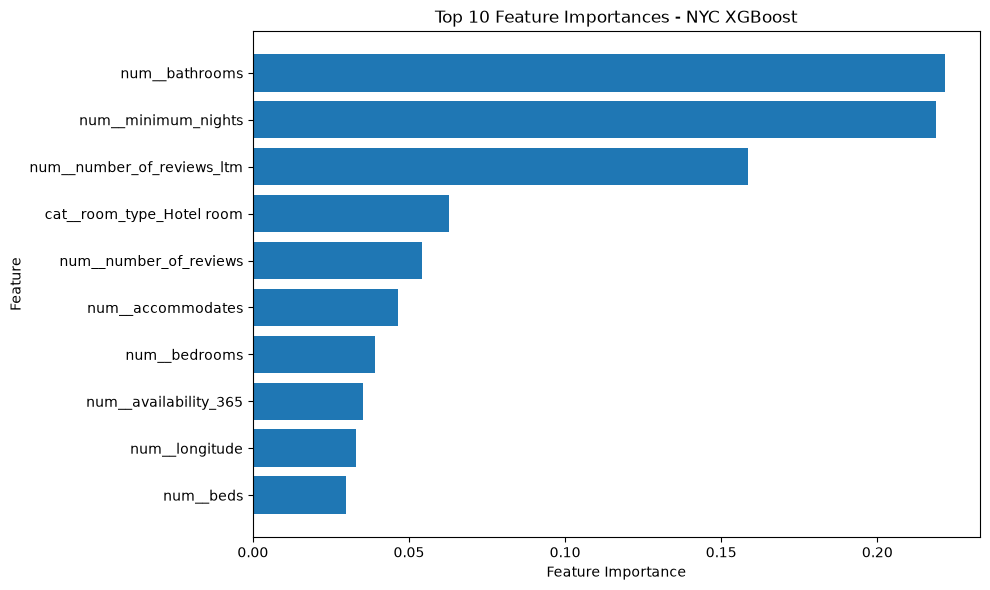

In [146]:
import matplotlib.pyplot as plt

top_features = importance_df.head(10).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - NYC XGBoost")
plt.tight_layout()
plt.show()


In [147]:
import pandas as pd

paris_path = "../data/Paris/listings (1).csv.gz"

paris = pd.read_csv(paris_path)

print("Paris dataset shape:", paris.shape)

print("\nFirst 5 rows:")
display(paris.head())

print("\nColumns:")
print(paris.columns.tolist())

print("\nData types:")
print(paris.dtypes)

Paris dataset shape: (77679, 90)

First 5 rows:


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,114543,https://www.airbnb.com/rooms/114543,20260616211535,2026-06-21,city scrape,Charming 55m² flat - Eiffel Tower,Fully furnished charming flat with lots of spa...,NaN,https://a0.muscache.com/pictures/airflow/Hosti...,581233,...,4.97,4.93,4.77,7511502831082,NaN,1,1,0,0,0.83
1,115107,https://www.airbnb.com/rooms/115107,20260616211535,2026-06-25,previous scrape,Charming two-bed apartment with balcony,This charming 60 square meter apartment is per...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,379042,...,5.00,4.40,4.40,7511002008206,NaN,2,1,1,0,0.22
2,115655,https://www.airbnb.com/rooms/115655,20260616211535,2026-06-20,city scrape,Family loft with a private courtyard,"Beautiful openplan loft situated in a private,...",NaN,https://a0.muscache.com/pictures/33160696/6171...,584977,...,4.69,4.04,4.40,7511805457226,NaN,1,1,0,0,1.24
3,120494,https://www.airbnb.com/rooms/120494,20260616211535,2026-06-19,city scrape,Romantic Hideout in Paris,"""As full of spirit as the month of May, as gor...",NaN,https://a0.muscache.com/pictures/833324/f66a6b...,606427,...,4.97,4.85,4.75,7511300905786,NaN,1,1,0,0,2.03
4,125686,https://www.airbnb.com/rooms/125686,20260616211535,2026-06-20,city scrape,Studio - République/Canal Saint Martin,"Tiny studio in central Paris, between the Mara...",NaN,https://a0.muscache.com/pictures/2704337/e28df...,624523,...,4.92,4.87,4.69,"Available with a mobility lease only (""bail mo...",NaN,1,1,0,0,0.79



Columns:
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote_price_per_night', 'price_quote_raw', 'm

In [148]:


print("Columns containing 'price':")
print([col for col in paris.columns if "price" in col.lower()])

print("\nPrice-related information:")
for col in paris.columns:
    if "price" in col.lower():
        print(f"\n--- {col} ---")
        print(paris[col].head())
        print("Missing:", paris[col].isna().sum())

Columns containing 'price':
['price', 'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote_price_per_night', 'price_quote_raw']

Price-related information:

--- price ---
0    $226.75
1        NaN
2    $225.00
3     $95.33
4     $37.40
Name: price, dtype: str
Missing: 29277

--- price_quote_checkin_date ---
0    2026-06-27
1           NaN
2    2026-06-24
3    2026-07-18
4    2026-08-05
Name: price_quote_checkin_date, dtype: str
Missing: 25869

--- price_quote_checkout_date ---
0    2026-07-01
1           NaN
2    2026-06-25
3    2026-07-21
4    2026-09-04
Name: price_quote_checkout_date, dtype: str
Missing: 25869

--- price_quote_total_price ---
0     907.0
1       NaN
2     225.0
3     286.0
4    1122.0
Name: price_quote_total_price, dtype: float64
Missing: 29277

--- price_quote_price_per_night ---
0    226.75
1       NaN
2    225.00
3     95.33
4     37.40
Name: price_quote_price_per_night, dtype: float64
Missing: 29277

--- price_quote_ra

Missing price values: 29277

Paris price statistics:
count    48402.000000
mean       321.230271
std        832.551387
min          3.200000
25%        131.330000
50%        205.500000
75%        342.000000
max      97003.050000
Name: price_clean, dtype: float64


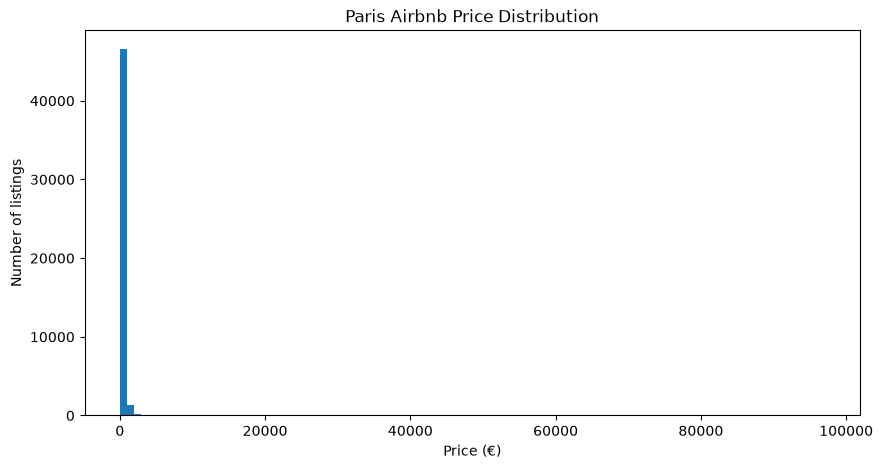

In [149]:


import numpy as np
import matplotlib.pyplot as plt

# Convert "$226.75" -> 226.75
paris["price_clean"] = (
    paris["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .replace("nan", np.nan)
    .astype(float)
)

print("Missing price values:", paris["price_clean"].isna().sum())

print("\nParis price statistics:")
print(paris["price_clean"].describe())

# Histogram
plt.figure(figsize=(10, 5))
plt.hist(paris["price_clean"].dropna(), bins=100)
plt.xlabel("Price (€)")
plt.ylabel("Number of listings")
plt.title("Paris Airbnb Price Distribution")
plt.show()


In [150]:
Q1 = paris["price_clean"].quantile(0.25)
Q3 = paris["price_clean"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = paris[
    (paris["price_clean"] < lower_bound) |
    (paris["price_clean"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))
print("Percentage of outliers:", len(outliers) / paris["price_clean"].notna().sum() * 100)

print("\nHighest 10 prices:")
print(
    paris["price_clean"]
    .dropna()
    .sort_values(ascending=False)
    .head(10)
)

Q1: 131.33
Q3: 342.0
IQR: 210.67
Lower bound: -184.67499999999998
Upper bound: 658.005
Number of outliers: 3799
Percentage of outliers: 7.8488492211065655

Highest 10 prices:
46967    97003.05
53054    70080.00
28834    57064.00
5371     34240.00
51626    24949.00
44209    22500.00
57875    20132.00
44210    20000.00
51046    19380.00
54987    17255.80
Name: price_clean, dtype: float64


In [151]:


core_features = [
    "price_clean",
    "room_type",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365"
]

print("Checking which core features exist in Paris:\n")

for col in core_features:
    print(f"{col}: {col in paris.columns}")

print("\nMissing values:")
print(paris[core_features].isna().sum())

Checking which core features exist in Paris:

price_clean: True
room_type: True
accommodates: True
bedrooms: True
beds: True
bathrooms: True
number_of_reviews: True
reviews_per_month: True
availability_365: True

Missing values:
price_clean          29277
room_type                0
accommodates             0
bedrooms             13956
beds                 30816
bathrooms            32371
number_of_reviews        0
reviews_per_month    15898
availability_365         0
dtype: int64


In [152]:
core_features = [
    "price_clean",
    "room_type",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365"
]


paris_model = paris[core_features].copy()

print("Original modeling shape:", paris_model.shape)


paris_model = paris_model.dropna(subset=["price_clean"]).copy()

print("Shape after removing missing prices:", paris_model.shape)


numeric_features = [
    "bedrooms",
    "beds",
    "bathrooms",
    "reviews_per_month"
]

for col in numeric_features:
    paris_model[col] = paris_model[col].fillna(
        paris_model[col].median()
    )

print("\nMissing values after preprocessing:")
print(paris_model.isna().sum())

print("\nTotal missing values:",
      paris_model.isna().sum().sum())

Original modeling shape: (77679, 9)
Shape after removing missing prices: (48402, 9)

Missing values after preprocessing:
price_clean          0
room_type            0
accommodates         0
bedrooms             0
beds                 0
bathrooms            0
number_of_reviews    0
reviews_per_month    0
availability_365     0
dtype: int64

Total missing values: 0


In [153]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X = paris_model.drop("price_clean", axis=1)
y = paris_model["price_clean"]

categorical_features = ["room_type"]
numerical_features = [
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365"
]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", "passthrough", numerical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

results = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    results[name] = {
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "R2": r2_score(y_test, predictions)
    }

results

{'Linear Regression': {'MAE': 177.86477576652013,
  'RMSE': np.float64(1068.7952854297805),
  'R2': 0.04438652321314274},
 'Random Forest': {'MAE': 168.63880804974974,
  'RMSE': np.float64(1071.5964864650755),
  'R2': 0.0393708323886619},
 'XGBoost': {'MAE': 164.140394565421,
  'RMSE': np.float64(1096.6676460684446),
  'R2': -0.006104911758777032}}

In [154]:
expanded_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "review_scores_rating",
    "number_of_reviews_ltm"
]

for col in expanded_features:
    print(col, col in paris.columns)

latitude True
longitude True
minimum_nights True
review_scores_rating True
number_of_reviews_ltm True


In [155]:
expanded_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "review_scores_rating",
    "number_of_reviews_ltm"
]

all_expanded_features = [
    "price_clean",
    "room_type",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365"
] + expanded_features

paris_expanded = paris[all_expanded_features].copy()

print("Paris expanded dataset shape:", paris_expanded.shape)
print("\nMissing values:")
print(paris_expanded.isna().sum())

Paris expanded dataset shape: (77679, 14)

Missing values:
price_clean              29277
room_type                    0
accommodates                 0
bedrooms                 13956
beds                     30816
bathrooms                32371
number_of_reviews            0
reviews_per_month        15898
availability_365             0
latitude                     0
longitude                    0
minimum_nights               0
review_scores_rating     15898
number_of_reviews_ltm        0
dtype: int64


In [156]:
paris_expanded = paris_expanded.dropna(subset=["price_clean"]).copy()

print("Shape after removing missing prices:", paris_expanded.shape)
print("\nRemaining missing values:")
print(paris_expanded.isna().sum())

Shape after removing missing prices: (48402, 14)

Remaining missing values:
price_clean                 0
room_type                   0
accommodates                0
bedrooms                 7757
beds                     4366
bathrooms                5853
number_of_reviews           0
reviews_per_month        8342
availability_365            0
latitude                    0
longitude                   0
minimum_nights              0
review_scores_rating     8342
number_of_reviews_ltm       0
dtype: int64


In [157]:
paris_expanded = paris_expanded.dropna().copy()

print("Final Paris expanded dataset shape:", paris_expanded.shape)
print("\nMissing values:")
print(paris_expanded.isna().sum())

Final Paris expanded dataset shape: (29037, 14)

Missing values:
price_clean              0
room_type                0
accommodates             0
bedrooms                 0
beds                     0
bathrooms                0
number_of_reviews        0
reviews_per_month        0
availability_365         0
latitude                 0
longitude                0
minimum_nights           0
review_scores_rating     0
number_of_reviews_ltm    0
dtype: int64


In [158]:
from sklearn.model_selection import train_test_split

X_paris = paris_expanded.drop("price_clean", axis=1)
y_paris = paris_expanded["price_clean"]

categorical_features = ["room_type"]

numerical_features = [
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365",
    "latitude",
    "longitude",
    "minimum_nights",
    "review_scores_rating",
    "number_of_reviews_ltm"
]

X_train_paris, X_test_paris, y_train_paris, y_test_paris = train_test_split(
    X_paris,
    y_paris,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train_paris.shape)
print("Test set:", X_test_paris.shape)

Training set: (23229, 13)
Test set: (5808, 13)


In [159]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

preprocessor_paris = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", "passthrough", numerical_features)
])

models_paris = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

results_paris = {}

for name, model in models_paris.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor_paris),
        ("model", model)
    ])

    pipeline.fit(X_train_paris, y_train_paris)
    predictions = pipeline.predict(X_test_paris)

    results_paris[name] = {
        "MAE": mean_absolute_error(y_test_paris, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test_paris, predictions)),
        "R2": r2_score(y_test_paris, predictions)
    }

results_paris

{'Linear Regression': {'MAE': 140.12642677439743,
  'RMSE': np.float64(340.3108247723737),
  'R2': 0.29911292247934385},
 'Random Forest': {'MAE': 126.28288779269971,
  'RMSE': np.float64(382.9341683707553),
  'R2': 0.11254822142631216},
 'XGBoost': {'MAE': 136.3303236641314,
  'RMSE': np.float64(556.3045054198079),
  'R2': -0.8729305781973022}}

In [160]:
xgb_pipeline_paris = Pipeline([
    ("preprocessor", preprocessor_paris),
    ("model", XGBRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipeline_paris.fit(X_train_paris, y_train_paris)

feature_names_paris = xgb_pipeline_paris.named_steps["preprocessor"].get_feature_names_out()
importances_paris = xgb_pipeline_paris.named_steps["model"].feature_importances_

feature_importance_paris = (
    pd.DataFrame({
        "Feature": feature_names_paris,
        "Importance": importances_paris
    })
    .sort_values("Importance", ascending=False)
)

print(feature_importance_paris)

                           Feature  Importance
6                        num__beds    0.424010
11                   num__latitude    0.113813
12                  num__longitude    0.103769
5                    num__bedrooms    0.064730
14       num__review_scores_rating    0.053938
13             num__minimum_nights    0.052444
4                num__accommodates    0.048698
9           num__reviews_per_month    0.046126
7                   num__bathrooms    0.022682
10           num__availability_365    0.017285
8           num__number_of_reviews    0.014517
15      num__number_of_reviews_ltm    0.014476
2      cat__room_type_Private room    0.010788
1        cat__room_type_Hotel room    0.007862
3       cat__room_type_Shared room    0.002498
0   cat__room_type_Entire home/apt    0.002364


In [161]:
print(paris_expanded["beds"].describe())

print("\nHighest beds values:")
print(paris_expanded["beds"].sort_values(ascending=False).head(20).to_list())

count    29037.000000
mean         2.054551
std          1.231442
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         17.000000
Name: beds, dtype: float64

Highest beds values:
[17.0, 15.0, 13.0, 13.0, 12.0, 12.0, 12.0, 12.0, 12.0, 11.0, 11.0, 11.0, 11.0, 11.0, 11.0, 11.0, 10.0, 10.0, 10.0, 10.0]


In [162]:
xgb_predictions_paris = xgb_pipeline_paris.predict(X_test_paris)

error_analysis_paris = pd.DataFrame({
    "Actual": y_test_paris.values,
    "Predicted": xgb_predictions_paris
})

error_analysis_paris["Absolute_Error"] = (
    error_analysis_paris["Actual"] - error_analysis_paris["Predicted"]
).abs()

print(error_analysis_paris.sort_values(
    "Absolute_Error",
    ascending=False
).head(10))

        Actual     Predicted  Absolute_Error
2926    195.14  27713.177734    27518.037734
5268  11470.00   1413.869995    10056.130005
1425   9999.00    447.304718     9551.695282
4432    513.00   9437.106445     8924.106445
3303   1822.00  10419.990234     8597.990234
1910    275.00   7989.815918     7714.815918
1222   8000.00   1291.502930     6708.497070
4169   6900.00    941.322876     5958.677124
2396    241.67   5390.954590     5149.284590
714    5081.00    247.642624     4833.357376


In [163]:
print(y_test_paris.describe())

print("\nHighest actual test prices:")
print(y_test_paris.sort_values(ascending=False).head(20).to_list())

count     5808.000000
mean       325.218917
std        406.526750
min          7.030000
25%        151.250000
50%        229.060000
75%        370.000000
max      11470.000000
Name: price_clean, dtype: float64

Highest actual test prices:
[11470.0, 9999.0, 8000.0, 8000.0, 6900.0, 5820.33, 5081.0, 4162.5, 4024.67, 3654.0, 3495.0, 3382.25, 3248.0, 3162.0, 3080.0, 3000.0, 2876.0, 2862.5, 2761.0, 2718.0]


In [164]:
berlin_path = "../data/berlin/listings (2).csv.gz"
berlin = pd.read_csv(berlin_path)

print("Berlin dataset shape:", berlin.shape)
print("\nFirst 5 rows:")
display(berlin.head())

print("\nColumns:")
print(berlin.columns.tolist())

Berlin dataset shape: (12776, 90)

First 5 rows:


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,3176,https://www.airbnb.com/rooms/3176,20260626225638,2026-07-03,previous scrape,Fabulous Flat in great Location,This beautiful first floor apartment is situa...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,3718,...,4.70,4.92,4.61,First name and Last name: Nicolas Krotz <br/> ...,NaN,1,1,0,0,0.72
1,9991,https://www.airbnb.com/rooms/9991,20260626225638,2026-06-27,city scrape,Geourgeous flat - outstanding views,4 bedroom with very large windows and outstand...,NaN,https://a0.muscache.com/pictures/42799131/59c8...,33852,...,5.00,4.86,4.86,03/Z/RA/003410-18,NaN,1,1,0,0,0.05
2,14325,https://www.airbnb.com/rooms/14325,20260626225638,2026-07-03,previous scrape,Studio Apartment in Prenzlauer Berg,The apartment is located on the upper second f...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,55531,...,4.85,4.60,4.45,NaN,NaN,2,2,0,0,0.13
3,17904,https://www.airbnb.com/rooms/17904,20260626225638,2026-07-03,previous scrape,Beautiful Kreuzberg studio - 3 months minimum,- bright studio with scenic view on a river - ...,NaN,https://a0.muscache.com/pictures/d9a6f8be-54b9...,68997,...,4.92,4.88,4.65,NaN,NaN,1,1,0,0,1.49
4,20858,https://www.airbnb.com/rooms/20858,20260626225638,2026-06-27,city scrape,Designer Loft in Berlin Mitte,Bright and sunny condo with two balconies in a...,NaN,https://a0.muscache.com/pictures/108232/205b19...,71331,...,4.55,4.92,4.40,03/Z/RA/009767-24,NaN,1,1,0,0,0.87



Columns:
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote_price_per_night', 'price_quote_raw', 'm

In [165]:
print(berlin["price"].head(10))
print("\nMissing price values:", berlin["price"].isna().sum())
print("\nPrice data type:", berlin["price"].dtype)

0    $160.71
1    $193.33
2        NaN
3     $10.88
4    $372.67
5     $16.86
6    $243.50
7        NaN
8    $212.50
9        NaN
Name: price, dtype: str

Missing price values: 4335

Price data type: str


In [166]:
import numpy as np

berlin["price_clean"] = (
    berlin["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .replace("nan", np.nan)
    .astype(float)
)

print("Missing price values:", berlin["price_clean"].isna().sum())
print("\nBerlin price statistics:")
print(berlin["price_clean"].describe())

Missing price values: 4335

Berlin price statistics:


count     8441.000000
mean       160.729973
std        204.998115
min          2.720000
25%         72.000000
50%        130.670000
75%        207.000000
max      10025.000000
Name: price_clean, dtype: float64


In [167]:
q1 = berlin["price_clean"].quantile(0.25)
q3 = berlin["price_clean"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = berlin[
    (berlin["price_clean"] < lower_bound) |
    (berlin["price_clean"] > upper_bound)
]

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))
print("Outlier percentage:", len(outliers) / berlin["price_clean"].notna().sum() * 100)

print("\nHighest prices:")
print(berlin["price_clean"].dropna().sort_values(ascending=False).head(10).to_list())

Q1: 72.0
Q3: 207.0
IQR: 135.0
Lower bound: -130.5
Upper bound: 409.5
Number of outliers: 362
Outlier percentage: 4.288591399123327

Highest prices:
[10025.0, 7999.2, 4458.0, 2956.0, 2296.0, 2270.4, 2269.0, 2100.0, 2033.33, 1825.0]


In [168]:
core_features = [
    "price_clean",
    "room_type",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365"
]

for col in core_features:
    print(col, col in berlin.columns)

print("\nMissing values:")
print(berlin[core_features].isna().sum())

price_clean True
room_type True
accommodates True
bedrooms True
beds True
bathrooms True
number_of_reviews True
reviews_per_month True
availability_365 True

Missing values:
price_clean          4335
room_type               0
accommodates            0
bedrooms             3420
beds                 6254
bathrooms            6651
number_of_reviews       0
reviews_per_month    2573
availability_365        0
dtype: int64


In [169]:
core_features = [
    "price_clean",
    "room_type",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365"
]

berlin_model = berlin[core_features].copy()

print("Original modeling shape:", berlin_model.shape)

berlin_model = berlin_model.dropna(subset=["price_clean"]).copy()

print("Shape after removing missing prices:", berlin_model.shape)

numeric_features = [
    "bedrooms",
    "beds",
    "bathrooms",
    "reviews_per_month"
]

for col in numeric_features:
    berlin_model[col] = berlin_model[col].fillna(berlin_model[col].median())

print("\nMissing values after preprocessing:")
print(berlin_model.isna().sum())

print("\nTotal missing values:", berlin_model.isna().sum().sum())

Original modeling shape: (12776, 9)
Shape after removing missing prices: (8441, 9)



Missing values after preprocessing:
price_clean          0
room_type            0
accommodates         0
bedrooms             0
beds                 0
bathrooms            0
number_of_reviews    0
reviews_per_month    0
availability_365     0
dtype: int64

Total missing values: 0


In [170]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_berlin = berlin_model.drop("price_clean", axis=1)
y_berlin = berlin_model["price_clean"]

categorical_features = ["room_type"]

numerical_features = [
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365"
]

preprocessor_berlin = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", "passthrough", numerical_features)
])

X_train_berlin, X_test_berlin, y_train_berlin, y_test_berlin = train_test_split(
    X_berlin,
    y_berlin,
    test_size=0.2,
    random_state=42
)

models_berlin = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

results_berlin = {}

for name, model in models_berlin.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor_berlin),
        ("model", model)
    ])

    pipeline.fit(X_train_berlin, y_train_berlin)
    predictions = pipeline.predict(X_test_berlin)

    results_berlin[name] = {
        "MAE": mean_absolute_error(y_test_berlin, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test_berlin, predictions)),
        "R2": r2_score(y_test_berlin, predictions)
    }

results_berlin

{'Linear Regression': {'MAE': 71.95194235600803,
  'RMSE': np.float64(114.75225662163335),
  'R2': 0.3352653534807507},
 'Random Forest': {'MAE': 64.6444317700268,
  'RMSE': np.float64(199.71580988137268),
  'R2': -1.0134958426198164},
 'XGBoost': {'MAE': 69.79747795797792,
  'RMSE': np.float64(266.11060411776435),
  'R2': -2.57478730862532}}

In [171]:
expanded_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "review_scores_rating",
    "number_of_reviews_ltm"
]

for col in expanded_features:
    print(col, col in berlin.columns)

latitude True
longitude True
minimum_nights True
review_scores_rating True
number_of_reviews_ltm True


In [172]:
expanded_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "review_scores_rating",
    "number_of_reviews_ltm"
]

all_expanded_features = [
    "price_clean",
    "room_type",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365"
] + expanded_features

berlin_expanded = berlin[all_expanded_features].copy()

print("Berlin expanded dataset shape:", berlin_expanded.shape)
print("\nMissing values:")
print(berlin_expanded.isna().sum())

Berlin expanded dataset shape: (12776, 14)

Missing values:
price_clean              4335
room_type                   0
accommodates                0
bedrooms                 3420
beds                     6254
bathrooms                6651
number_of_reviews           0
reviews_per_month        2573
availability_365            0
latitude                    0
longitude                   0
minimum_nights              3
review_scores_rating     2573
number_of_reviews_ltm       0
dtype: int64


In [173]:
berlin_expanded = berlin_expanded.dropna(subset=["price_clean"]).copy()

print("Shape after removing missing prices:", berlin_expanded.shape)

berlin_expanded = berlin_expanded.dropna().copy()

print("\nFinal Berlin expanded dataset shape:", berlin_expanded.shape)

print("\nMissing values:")
print(berlin_expanded.isna().sum())

Shape after removing missing prices: (8441, 14)

Final Berlin expanded dataset shape: (4368, 14)

Missing values:
price_clean              0
room_type                0
accommodates             0
bedrooms                 0
beds                     0
bathrooms                0
number_of_reviews        0
reviews_per_month        0
availability_365         0
latitude                 0
longitude                0
minimum_nights           0
review_scores_rating     0
number_of_reviews_ltm    0
dtype: int64


In [174]:
X_berlin_expanded = berlin_expanded.drop("price_clean", axis=1)
y_berlin_expanded = berlin_expanded["price_clean"]

categorical_features = ["room_type"]

numerical_features = [
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365",
    "latitude",
    "longitude",
    "minimum_nights",
    "review_scores_rating",
    "number_of_reviews_ltm"
]

X_train_berlin_expanded, X_test_berlin_expanded, y_train_berlin_expanded, y_test_berlin_expanded = train_test_split(
    X_berlin_expanded,
    y_berlin_expanded,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train_berlin_expanded.shape)
print("Test set:", X_test_berlin_expanded.shape)

Training set: (3494, 13)
Test set: (874, 13)


In [175]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

preprocessor_berlin_expanded = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", "passthrough", numerical_features)
])

models_berlin_expanded = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

results_berlin_expanded = {}

for name, model in models_berlin_expanded.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor_berlin_expanded),
        ("model", model)
    ])

    pipeline.fit(X_train_berlin_expanded, y_train_berlin_expanded)
    predictions = pipeline.predict(X_test_berlin_expanded)

    results_berlin_expanded[name] = {
        "MAE": mean_absolute_error(y_test_berlin_expanded, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test_berlin_expanded, predictions)),
        "R2": r2_score(y_test_berlin_expanded, predictions)
    }

results_berlin_expanded

{'Linear Regression': {'MAE': 64.83323528700157,
  'RMSE': np.float64(107.89110499167184),
  'R2': 0.4846978473714273},
 'Random Forest': {'MAE': 61.29858558352402,
  'RMSE': np.float64(153.77450755797736),
  'R2': -0.04678951621871974},
 'XGBoost': {'MAE': 62.022938779660706,
  'RMSE': np.float64(150.499660818145),
  'R2': -0.0026785329269605196}}

In [176]:
xgb_pipeline_berlin = Pipeline([
    ("preprocessor", preprocessor_berlin_expanded),
    ("model", XGBRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipeline_berlin.fit(
    X_train_berlin_expanded,
    y_train_berlin_expanded
)

feature_names_berlin = xgb_pipeline_berlin.named_steps["preprocessor"].get_feature_names_out()
importances_berlin = xgb_pipeline_berlin.named_steps["model"].feature_importances_

feature_importance_berlin = (
    pd.DataFrame({
        "Feature": feature_names_berlin,
        "Importance": importances_berlin
    })
    .sort_values("Importance", ascending=False)
)

print(feature_importance_berlin)

                           Feature  Importance
10           num__availability_365    0.220800
11                   num__latitude    0.200900
4                num__accommodates    0.147247
3       cat__room_type_Shared room    0.082023
7                   num__bathrooms    0.078112
5                    num__bedrooms    0.072240
2      cat__room_type_Private room    0.068854
13             num__minimum_nights    0.021678
14       num__review_scores_rating    0.018742
12                  num__longitude    0.018551
8           num__number_of_reviews    0.016859
15      num__number_of_reviews_ltm    0.016446
9           num__reviews_per_month    0.013398
6                        num__beds    0.009304
1        cat__room_type_Hotel room    0.007684
0   cat__room_type_Entire home/apt    0.007163


In [177]:
comparison_results = []

for city, results in [
    ("NYC", results),
    ("Paris", results_paris),
    ("Berlin", results_berlin)
]:
    for model, metrics in results.items():
        comparison_results.append({
            "City": city,
            "Model": model,
            "MAE": metrics["MAE"],
            "RMSE": metrics["RMSE"],
            "R2": metrics["R2"]
        })

core_comparison = pd.DataFrame(comparison_results)

print("Core Model Comparison")
display(core_comparison.round(4))

Core Model Comparison


,City,Model,MAE,RMSE,R2
0,NYC,Linear Regression,177.8648,1068.7953,0.0444
1,NYC,Random Forest,168.6388,1071.5965,0.0394
2,NYC,XGBoost,164.1404,1096.6676,-0.0061
3,Paris,Linear Regression,140.1264,340.3108,0.2991
4,Paris,Random Forest,126.2829,382.9342,0.1125
5,Paris,XGBoost,136.3303,556.3045,-0.8729
6,Berlin,Linear Regression,71.9519,114.7523,0.3353
7,Berlin,Random Forest,64.6444,199.7158,-1.0135
8,Berlin,XGBoost,69.7975,266.1106,-2.5748


In [178]:
print("NYC:", "results" in globals())
print("Paris:", "results_paris" in globals())
print("Berlin:", "results_berlin" in globals())

NYC: True
Paris: True
Berlin: True


In [179]:
import pandas as pd

final_core_results = pd.DataFrame([
    ["NYC", "Linear Regression", 173.27, 481.96, 0.1693],
    ["NYC", "Random Forest", 159.50, 501.86, 0.0993],
    ["NYC", "XGBoost", 157.51, 483.44, 0.1642],
    ["Paris", "Linear Regression", 177.8648, 1068.7953, 0.0444],
    ["Paris", "Random Forest", 168.6388, 1071.5965, 0.0394],
    ["Paris", "XGBoost", 164.1404, 1096.6676, -0.0061],
    ["Berlin", "Linear Regression", 71.9519, 114.7523, 0.3353],
    ["Berlin", "Random Forest", 64.6444, 199.7158, -1.0135],
    ["Berlin", "XGBoost", 69.7975, 266.1106, -2.5748]
], columns=["City", "Model", "MAE", "RMSE", "R2"])

display(final_core_results)

,City,Model,MAE,RMSE,R2
0,NYC,Linear Regression,173.2700,481.9600,0.1693
1,NYC,Random Forest,159.5000,501.8600,0.0993
2,NYC,XGBoost,157.5100,483.4400,0.1642
3,Paris,Linear Regression,177.8648,1068.7953,0.0444
4,Paris,Random Forest,168.6388,1071.5965,0.0394
5,Paris,XGBoost,164.1404,1096.6676,-0.0061
6,Berlin,Linear Regression,71.9519,114.7523,0.3353
7,Berlin,Random Forest,64.6444,199.7158,-1.0135
8,Berlin,XGBoost,69.7975,266.1106,-2.5748


In [180]:
final_expanded_results = pd.DataFrame([
    ["NYC", "Linear Regression", 163.97, 473.27, 0.1990],
    ["NYC", "Random Forest", 106.58, 298.61, 0.5072],
    ["NYC", "XGBoost", 104.03, 291.31, 0.5310],
    ["Paris", "Linear Regression", 140.1264, 340.3108, 0.2991],
    ["Paris", "Random Forest", 126.2829, 382.9342, 0.1125],
    ["Paris", "XGBoost", 136.3303, 556.3045, -0.8729],
    ["Berlin", "Linear Regression", 64.8332, 107.8911, 0.4847],
    ["Berlin", "Random Forest", 61.2986, 153.7745, -0.0468],
    ["Berlin", "XGBoost", 62.0229, 150.4997, -0.0027]
], columns=["City", "Model", "MAE", "RMSE", "R2"])

display(final_expanded_results)

,City,Model,MAE,RMSE,R2
0,NYC,Linear Regression,163.9700,473.2700,0.1990
1,NYC,Random Forest,106.5800,298.6100,0.5072
2,NYC,XGBoost,104.0300,291.3100,0.5310
3,Paris,Linear Regression,140.1264,340.3108,0.2991
4,Paris,Random Forest,126.2829,382.9342,0.1125
5,Paris,XGBoost,136.3303,556.3045,-0.8729
6,Berlin,Linear Regression,64.8332,107.8911,0.4847
7,Berlin,Random Forest,61.2986,153.7745,-0.0468
8,Berlin,XGBoost,62.0229,150.4997,-0.0027


In [181]:
best_models = final_expanded_results.loc[
    final_expanded_results.groupby("City")["R2"].idxmax()
].reset_index(drop=True)

display(best_models)

,City,Model,MAE,RMSE,R2
0,Berlin,Linear Regression,64.8332,107.8911,0.4847
1,NYC,XGBoost,104.0300,291.3100,0.5310
2,Paris,Linear Regression,140.1264,340.3108,0.2991


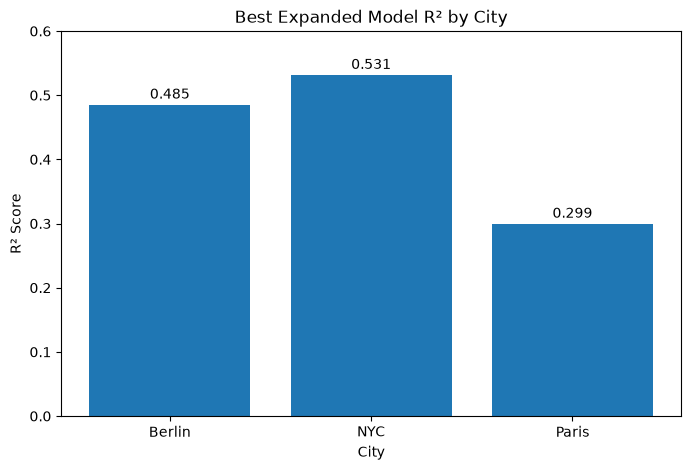

In [182]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(best_models["City"], best_models["R2"])

plt.xlabel("City")
plt.ylabel("R² Score")
plt.title("Best Expanded Model R² by City")
plt.ylim(0, 0.6)

for i, value in enumerate(best_models["R2"]):
    plt.text(i, value + 0.01, f"{value:.3f}", ha="center")

plt.show()

In [183]:
error_comparison = best_models[["City", "Model", "MAE", "RMSE"]].copy()

display(error_comparison)

,City,Model,MAE,RMSE
0,Berlin,Linear Regression,64.8332,107.8911
1,NYC,XGBoost,104.0300,291.3100
2,Paris,Linear Regression,140.1264,340.3108


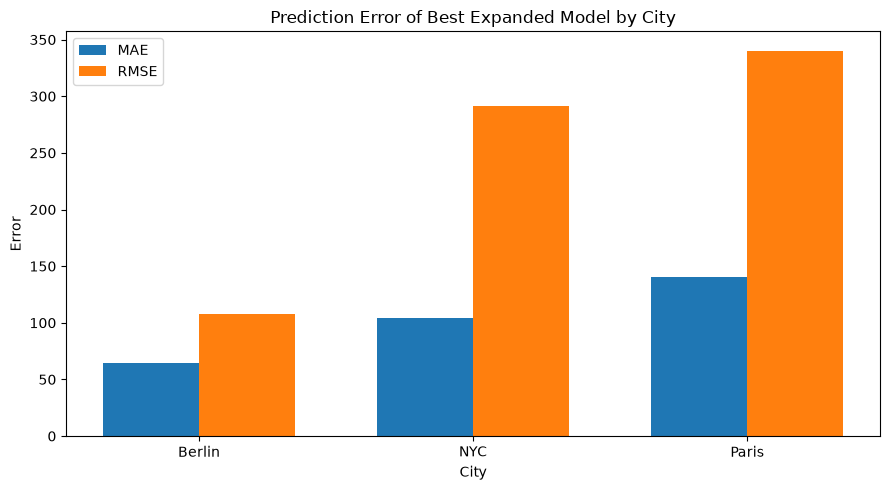

In [184]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(error_comparison))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width / 2, error_comparison["MAE"], width, label="MAE")
plt.bar(x + width / 2, error_comparison["RMSE"], width, label="RMSE")

plt.xticks(x, error_comparison["City"])
plt.xlabel("City")
plt.ylabel("Error")
plt.title("Prediction Error of Best Expanded Model by City")
plt.legend()
plt.tight_layout()

plt.show()

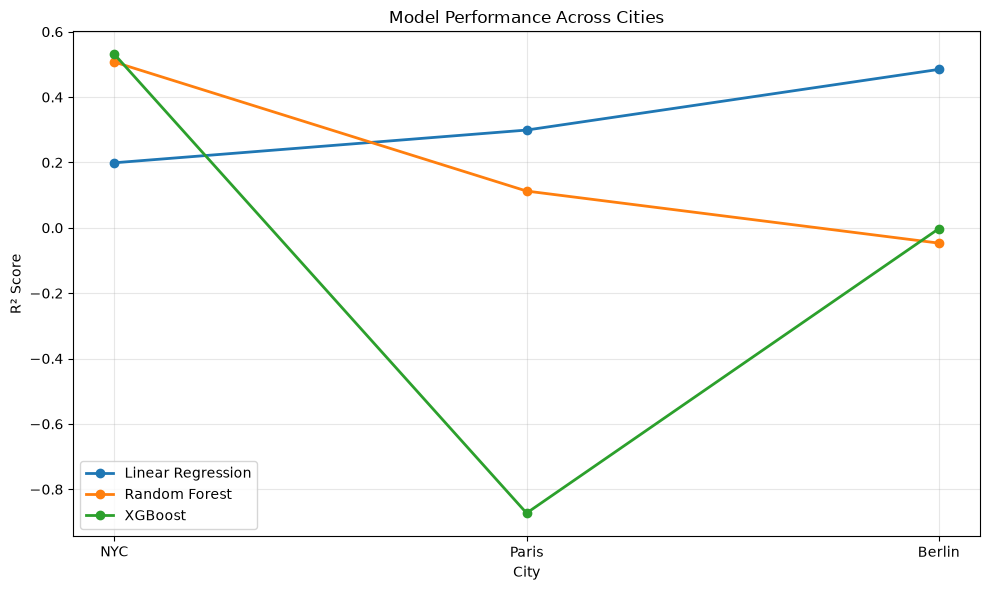

In [185]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for model in final_expanded_results["Model"].unique():
    data = final_expanded_results[final_expanded_results["Model"] == model]
    plt.plot(data["City"], data["R2"], marker="o", linewidth=2, label=model)

plt.xlabel("City")
plt.ylabel("R² Score")
plt.title("Model Performance Across Cities")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

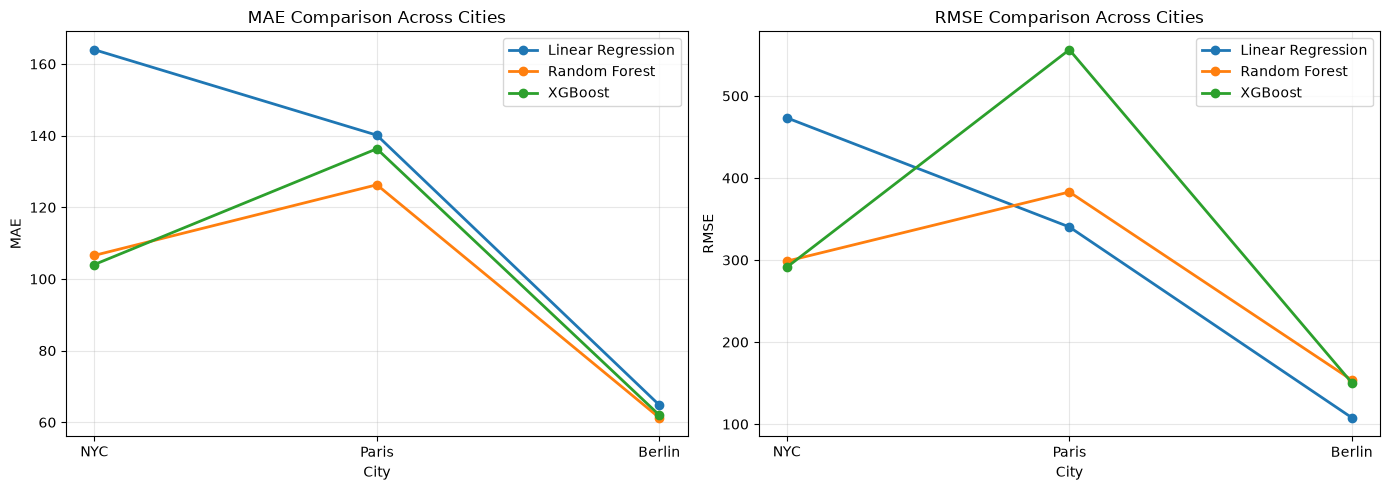

In [186]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model in final_expanded_results["Model"].unique():
    data = final_expanded_results[final_expanded_results["Model"] == model]
    axes[0].plot(data["City"], data["MAE"], marker="o", linewidth=2, label=model)
    axes[1].plot(data["City"], data["RMSE"], marker="o", linewidth=2, label=model)

axes[0].set_xlabel("City")
axes[0].set_ylabel("MAE")
axes[0].set_title("MAE Comparison Across Cities")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("City")
axes[1].set_ylabel("RMSE")
axes[1].set_title("RMSE Comparison Across Cities")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [187]:
final_expanded_results.sort_values(["City", "R2"], ascending=[True, False]).reset_index(drop=True)

,City,Model,MAE,RMSE,R2
0,Berlin,Linear Regression,64.8332,107.8911,0.4847
1,Berlin,XGBoost,62.0229,150.4997,-0.0027
2,Berlin,Random Forest,61.2986,153.7745,-0.0468
3,NYC,XGBoost,104.0300,291.3100,0.5310
4,NYC,Random Forest,106.5800,298.6100,0.5072
5,NYC,Linear Regression,163.9700,473.2700,0.1990
6,Paris,Linear Regression,140.1264,340.3108,0.2991
7,Paris,Random Forest,126.2829,382.9342,0.1125
8,Paris,XGBoost,136.3303,556.3045,-0.8729


# Final Analysis and Conclusion

## Model Comparison

The performance of Linear Regression, Random Forest, and XGBoost was evaluated across NYC, Paris, and Berlin using MAE, RMSE, and R².

The results show that no single model consistently performs best across all three cities. XGBoost achieved the highest R² for NYC with an R² of 0.5310, while Linear Regression achieved the highest R² for Berlin (0.4847) and Paris (0.2991).

For NYC, XGBoost achieved the lowest MAE and RMSE among the three models, indicating the strongest overall predictive performance.

For Paris, Random Forest achieved the lowest MAE of 126.28, while Linear Regression achieved the lowest RMSE of 340.31 and the highest R² of 0.2991.

For Berlin, Random Forest achieved the lowest MAE of 61.30, but Linear Regression achieved substantially lower RMSE of 107.89 and the highest R² of 0.4847.

## Effect of Expanded Features

Adding geographic, review, and listing-related features improved the predictive performance compared with the core feature set, particularly for NYC and Berlin.

The expanded feature set included latitude, longitude, minimum_nights, review_scores_rating, and number_of_reviews_ltm in addition to the original listing features.

## City-Level Differences

The results indicate that model performance is highly dependent on the characteristics of each city's Airbnb market. Differences in price distributions, geographic effects, listing characteristics, and extreme-price listings influence the performance of the models.

Paris showed substantially larger RMSE values, indicating the presence of larger prediction errors associated with high-priced listings. The presence of extreme prices also affected the performance of tree-based models.

## Final Conclusion

The experiments demonstrate that Airbnb price prediction is strongly dependent on the characteristics of the target city. XGBoost performed best for NYC, whereas Linear Regression provided the strongest overall performance for Paris and Berlin based on R² and RMSE.

Therefore, the results do not support selecting a single universally optimal model for all cities. Instead, model selection should be performed based on the characteristics and evaluation results of each individual market.